# Cats & Dogs Small Dataset: Comparison of a Base CNN and Transfer Learning Models (VGG16, ResNet50, and EfficientNetB0)

Bu çalışma, mevcut Cats & Dogs Small Dataset notebook'unun (https://www.kaggle.com/code/fatihhattatoglu/cat-dogs) genişletilmiş bir versiyonudur. Orijinal veri bölünmesi (train/test) korunarak, Base CNN modeline ek olarak VGG16, ResNet50 ve EfficientNetB0 transfer öğrenme modelleri aynı eğitim ve test verileri üzerinde eğitilmiş ve performansları karşılaştırılmıştır. Bu yaklaşım, farklı model mimarilerinin aynı deneysel koşullar altında objektif olarak değerlendirilmesini sağlamaktadır.

# 1.  Import Libraries 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cats-and-dogs/val.csv
/kaggle/input/cats-and-dogs/train.csv
/kaggle/input/cats-and-dogs/val/classname.txt
/kaggle/input/cats-and-dogs/val/dog/havanese_144_jpg.rf.d3e2e8cb9a7801e61894e372c4f1e1bb.jpg
/kaggle/input/cats-and-dogs/val/dog/american_pit_bull_terrier_135_jpg.rf.f23ba7a8a1017fc71e62dcdeb3af9fa9.jpg
/kaggle/input/cats-and-dogs/val/dog/great_pyrenees_190_jpg.rf.ebd07e7aae6a416425fa1f3c89872b61.jpg
/kaggle/input/cats-and-dogs/val/dog/great_pyrenees_144_jpg.rf.d416d150a51cd8c6ae1489957c49e01b.jpg
/kaggle/input/cats-and-dogs/val/dog/chihuahua_17_jpg.rf.d97aa2c7e61de5128686d82b87c95215.jpg
/kaggle/input/cats-and-dogs/val/dog/english_cocker_spaniel_17_jpg.rf.f22312874dde3803847df16bcfe12f83.jpg
/kaggle/input/cats-and-dogs/val/dog/american_bulldog_148_jpg.rf.f0a7b86489589aa05534a6f8cb0fe70a.jpg
/kaggle/input/cats-and-dogs/val/dog/english_cocker_spaniel_121_jpg.rf.db065f7b515f83644b2fcb7525073d0b.jpg
/kaggle/input/cats-and-dogs/val/dog/pomeranian_134_jpg.rf.fb1b528eaddde0

In [2]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Hide all warnings
import warnings
warnings.filterwarnings("ignore")

# Hide deprecated warnings in Keras and TensorFlow
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2026-07-15 22:42:36.560593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784155357.011679      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784155357.144054      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print("TensorFlow Version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))
print("Available CPUs:", tf.config.list_physical_devices('CPU'))

TensorFlow Version: 2.18.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Available CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# 2. Connect Data 

In [4]:
train_path = '/kaggle/input/cats-and-dogs/train'
test_path = '/kaggle/input/cats-and-dogs/val'

In [5]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['dog', 'classname.txt', 'cat']
['dog', 'classname.txt', 'cat']


In [6]:
print("Train Cat :", len(os.listdir(train_path + "/cat")))
print("Train Dog :", len(os.listdir(train_path + "/dog")))

print("Test Cat :", len(os.listdir(test_path + "/cat")))
print("Test Dog :", len(os.listdir(test_path + "/dog")))

Train Cat : 95
Train Dog : 180
Test Cat : 24
Test Dog : 46


In [7]:
os.listdir(train_path+'/cat')[0]  

'Egyptian_Mau_108_jpg.rf.afd725b697520d03a6d12b912e6333e6.jpg'

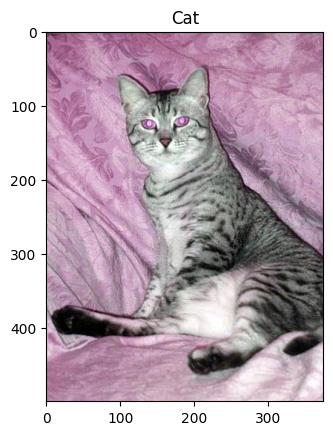

(500, 375, 3)


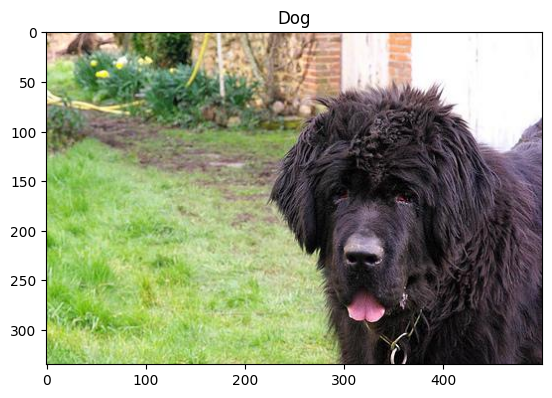

(335, 500, 3)


In [8]:

cat_file = os.listdir(train_path + '/cat')[0]
dog_file = os.listdir(train_path + '/dog')[0]

cat_path = os.path.join(train_path, 'cat', cat_file)
dog_path = os.path.join(train_path, 'dog', dog_file)

cat_img = imread(cat_path)
dog_img = imread(dog_path)

plt.imshow(cat_img)
plt.title("Cat")
plt.show()

print(cat_img.shape)

plt.imshow(dog_img)
plt.title("Dog")
plt.show()

print(dog_img.shape)

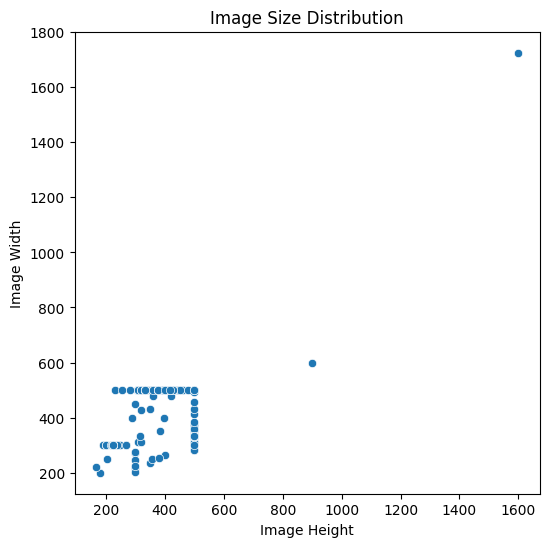

In [9]:
x = []
y = []

for cls in ['cat', 'dog']:
    folder = os.path.join(train_path, cls)

    for image in os.listdir(folder):

        img = imread(os.path.join(folder, image))

        d1, d2 = img.shape[:2]

        x.append(d1)
        y.append(d2)

plt.figure(figsize=(6,6))
sns.scatterplot(x=x, y=y)

plt.xlabel("Image Height")
plt.ylabel("Image Width")
plt.title("Image Size Distribution")
plt.show()

In [10]:
print("Min Height :", np.min(x))
print("Max Height :", np.max(x))

print("Min Width  :", np.min(y))
print("Max Width  :", np.max(y))

print("Average Height :", np.mean(x))
print("Average Width  :", np.mean(y))

Min Height : 165
Max Height : 1600
Min Width  : 200
Max Width  : 1725
Average Height : 381.70545454545453
Average Width  : 443.1636363636364


In [11]:
# Bu yeni çalışmada Base Model ,VGG16, ResNet50 ve EfficientNetB0 kullanılarak karşılaştırma yapılacaktır.
# Bu modeller için rastgele bir boyut seçmek yerine, önceden eğitildikleri giriş boyutunu kullanılacaktır =(224, 224, 3)

image_shape = (224, 224, 3)

# 3. Image GeneratorImageDataGenerator: Data Augmentation and Preprocessing

Bu çalışmada modeller arasında adil bir karşılaştırma yapılabilmesi için tüm modellerde aynı veri artırma (data augmentation) stratejisi uygulanmıştır. Veri setinin yalnızca 275 eğitim görüntüsünden oluşması nedeniyle, veri artırma teknikleri modelin aşırı öğrenmesini (overfitting) azaltmak ve genelleme performansını artırmak amacıyla kullanılmıştır.

Base CNN modeli için görüntüler 1/255 ile normalize edilmiştir (rescale=1./255). Transfer öğrenme modelleri (VGG16, ResNet50 ve EfficientNetB0) için ise Keras Applications (https://keras.io/api/applications/) tarafından önerilen modele özgü ön işleme (preprocessing) fonksiyonları kullanılmıştır. Böylece her önceden eğitilmiş model, ImageNet üzerinde eğitildiği giriş formatında beslenmiş ve modellerin performansları kendi önerilen ön işleme yöntemleriyle değerlendirilmiştir.

Bu yaklaşım, modeller arasında daha güvenilir ve bilimsel açıdan daha doğru bir performans karşılaştırması yapılmasını sağlamaktadır. 

# 4. Base CNN

## 4.1. Base CNN Model Image Generator

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image Generator
image_gen = ImageDataGenerator( rotation_range=15,   # Görüntüyü en fazla 15 derece döndürür.
                                width_shift_range=0.10,     # Görüntüyü yatay yönde genişliğinin en fazla %10'u kadar kaydırır.
                                height_shift_range=0.10,    # Görüntüyü dikey yönde yüksekliğinin en fazla %10'u kadar kaydırır.
                                rescale=1./255,             # Piksel değerlerini 0-255 aralığından 0-1 aralığına ölçeklendirir.
                                shear_range=0.10,           # Görüntüye en fazla %10 oranında eğme dönüşümü uygular.
                                zoom_range=0.10,            # Görüntüye en fazla %10 oranında yakınlaştırma/uzaklaştırma uygular.
                                horizontal_flip=True,       # Görüntüyü yatay eksende rastgele aynalar.
                                fill_mode='nearest'         # Oluşan boş pikselleri en yakın komşu piksel değerleriyle doldurur.
                            )

## 4.2. Image Generation for Train Data

In [13]:
batch_size = 32

train_image_gen = image_gen.flow_from_directory(train_path,
                                                target_size=(224,224),
                                                color_mode='rgb',
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=True
                                              )

Found 275 images belonging to 2 classes.


## 4.3. No Image Generation for Test Data

In [14]:
image_gen_test = ImageDataGenerator(rescale=1./255)

test_image_gen = image_gen_test.flow_from_directory(test_path,
                                                    target_size=(224,224),
                                                    color_mode='rgb',
                                                    batch_size=batch_size,
                                                    class_mode='binary',
                                                    shuffle=False
                                                   )

# Test veri setinde yalnızca rescale=1./255 uygulanmıştır.
# Veri artırma teknikleri kullanılmamıştır çünkü test verisinin amacı,modelin eğitim sırasında görmediği orijinal görüntüler üzerinde gerçek
# genelleme performansını objektif olarak değerlendirmektir. Eğitim ve test verilerinin aynı piksel ölçeğinde olması ise
#tutarlı ve güvenilir sonuçlar elde edilmesini sağlar.

Found 70 images belonging to 2 classes.


## 4.4. Creating the Manual Base CNN Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


BaseCNN_model = Sequential()

# 1. Convolution Block
BaseCNN_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3), kernel_regularizer=l2(0.001)))
BaseCNN_model.add(MaxPooling2D((2,2)))
BaseCNN_model.add(BatchNormalization())

# 2. Convolution Block
BaseCNN_model.add(Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
BaseCNN_model.add(MaxPooling2D((2,2)))
BaseCNN_model.add(BatchNormalization())

# 3. Convolution Block
BaseCNN_model.add(Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
BaseCNN_model.add(MaxPooling2D((2,2)))
BaseCNN_model.add(BatchNormalization())

# Flatten yerine parametre patlamasını önleyen Global Average Pooling
BaseCNN_model.add(GlobalAveragePooling2D())

# ANN / Fully Connected Layer
BaseCNN_model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
BaseCNN_model.add(Dropout(0.3))  # Ezberlemeyi önlemek için daha dengeli bir Dropout

# Output Layer
BaseCNN_model.add(Dense(1, activation='sigmoid'))

# Küçük veri kümesi için optimize edilmiş düşük öğrenme oranlı Adam Optimizer
BaseCNN_model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Model özetini kontrol edelim (Parametre sayısının ne kadar düştüğünü göreceksiniz)


I0000 00:00:1784155386.836853      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784155386.840079      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
BaseCNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 111, 111, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 54, 54, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 26, 26, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

Base CNN modeli, transfer öğrenme (transfer learning) modelleriyle adil ve sağlıklı bir karşılaştırma yapılabilmesi amacıyla referans model olarak tasarlanmıştır. Modelde, görüntülerden düşük ve yüksek seviyeli özelliklerin aşamalı olarak öğrenilebilmesi için filtre sayısı konvolüsyon bloklarında kademeli olarak artırılmıştır (sırasıyla 32, 64 ve 128 filtre). Her konvolüsyon bloğunun ardından gelen MaxPooling2D katmanları ile boyutsal küçülme sağlanarak hesaplama maliyeti azaltılmış; Batch Normalization katmanları ile de eğitim sürecinin kararlı hale getirilmesi hedeflenmiştir.

Sınıflandırma aşamasında, parametre sayısının kontrolsüz artışını (parametre patlamasını) engellemek ve küçük veri setinden kaynaklanan aşırı öğrenme (overfitting) riskini minimize etmek amacıyla klasik Flatten katmanı yerine Global Average Pooling (GAP) katmanı tercih edilmiştir. Modelin genelleştirme yeteneğini artırmak için ağırlıklara L2 düzenlileştirmesi (regularization) uygulanmış ve bilgi kaybını önlemek amacıyla dengeli bir Dropout (%30) oranı kullanılmıştır. Çıktı katmanında ikili sınıflandırmaya (binary classification) uygun olarak Sigmoid aktivasyon fonksiyonu tercih edilmiştir. Model, kayıp dalgalanmalarını engellemek amacıyla 0.0001 öğrenme oranına (learning rate) sahip Adam optimizasyon algoritması ve ikili çapraz entropi (binary cross-entropy) kayıp fonksiyonu ile derlenmiştir.

## 4.5.Early Stopping

In [17]:
#  Early Stopping Ayarı (Daha esnek bir patience değeri ile)
early_stop = EarlyStopping( monitor='val_loss',
                            patience=8,                 # Modeli hemen durdurmaması için sabır süresini biraz artırdık
                            restore_best_weights=True,  # En iyi performansı gösteren epoch ağırlıklarına geri döner
                            verbose=1
                        )

## 4.6. Model Training

In [18]:
from sklearn.utils import class_weight
# Sınıf Ağırlıklarını Hesaplama (Sınıf çöküşünü engellemek için kritik) train_image_gen içindeki etiket dağılımına göre otomatik ağırlık hesaplar
class_weights = class_weight.compute_class_weight( class_weight='balanced',
                                                   classes=np.unique(train_image_gen.classes),
                                                   y=train_image_gen.classes
                                                  )
class_weights_dict = dict(enumerate(class_weights))

#  Model Eğitimi (Model fit)
results = BaseCNN_model.fit(train_image_gen,
                            epochs=30,
                            validation_data=test_image_gen,
                            class_weight=class_weights_dict,  # Hesaplanan sınıf ağırlıklarını modele besliyoruz
                            callbacks=[early_stop]
                           )

Epoch 1/30


I0000 00:00:1784155395.946168      79 service.cc:148] XLA service 0x7bfb48012970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784155395.947838      79 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1784155395.947885      79 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1784155396.667532      79 cuda_dnn.cc:529] Loaded cuDNN version 90300


2/9 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4688 - loss: 0.9226 

I0000 00:00:1784155403.830044      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4592 - loss: 0.9540 - val_accuracy: 0.3429 - val_loss: 0.9621
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 511ms/step - accuracy: 0.5367 - loss: 0.9156 - val_accuracy: 0.3429 - val_loss: 0.9743
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 502ms/step - accuracy: 0.6016 - loss: 0.8797 - val_accuracy: 0.3429 - val_loss: 0.9896
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 482ms/step - accuracy: 0.6098 - loss: 0.9270 - val_accuracy: 0.3429 - val_loss: 1.0044
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 482ms/step - accuracy: 0.6197 - loss: 0.8679 - val_accuracy: 0.3429 - val_loss: 1.0204
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 505ms/step - accuracy: 0.6223 - loss: 0.8693 - val_accuracy: 0.3429 - val_loss: 1.0316
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 482ms/step - accuracy: 0.5857 - loss: 0.8826 - val_accuracy: 0.3429 - val_loss: 1.0410
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 488ms/step - accuracy: 0.6998 - loss: 0.8240 - val_accuracy: 0.3429 - val_loss: 1.0528
Epoch

### 4.6.1 Base CNN Summary

In [19]:
summary = pd.DataFrame(BaseCNN_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.454545,0.965447,0.342857,0.962072
1,0.567273,0.917639,0.342857,0.974346
2,0.610909,0.877579,0.342857,0.989600
3,0.618182,0.899077,0.342857,1.004420
4,0.629091,0.858650,0.342857,1.020358


### 4.6.2. Base CNN Model Loss Figure & Accuracy Figure

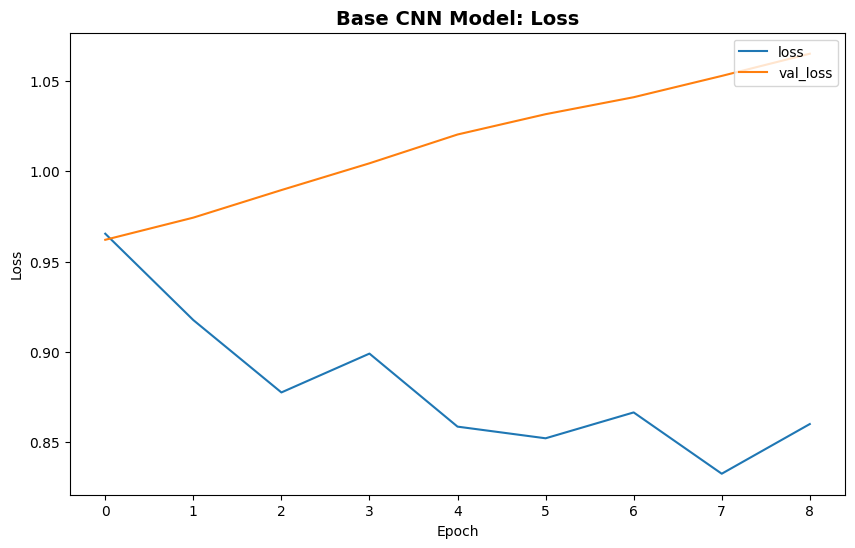

In [20]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.title("Base CNN Model: Loss", fontsize=14, fontweight='bold')
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

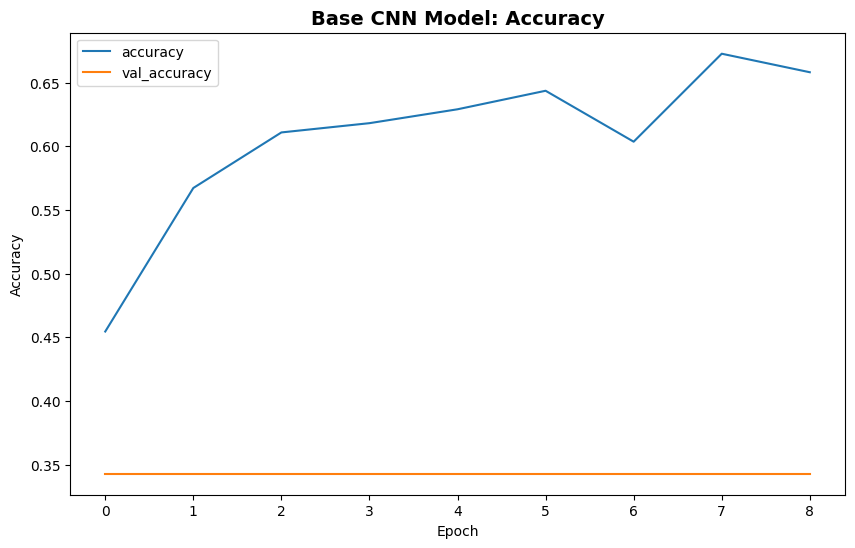

In [21]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.title("Base CNN Model: Accuracy", fontsize=14, fontweight='bold')
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

### 4.6.3. Base CNN Model Eval Metrics

In [22]:
BaseCNN_model.metrics_names

['loss', 'compile_metrics']

In [23]:
BaseCNN_model.evaluate(test_image_gen)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4527 - loss: 0.9566 


[0.9620723128318787, 0.34285715222358704]

In [24]:
pred_probabilities = BaseCNN_model.predict(test_image_gen)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step


In [25]:
pred_probabilities

array([[0.48259738],
       [0.48882276],
       [0.48952043],
       [0.4867319 ],
       [0.485645  ],
       [0.48829743],
       [0.48747328],
       [0.4858342 ],
       [0.48767546],
       [0.48789966],
       [0.48642132],
       [0.48621172],
       [0.48650607],
       [0.48847327],
       [0.4876661 ],
       [0.4879089 ],
       [0.48760226],
       [0.4867339 ],
       [0.48591426],
       [0.48718956],
       [0.48928377],
       [0.4897916 ],
       [0.4872256 ],
       [0.48865402],
       [0.4892646 ],
       [0.48918325],
       [0.48780695],
       [0.4901278 ],
       [0.4856769 ],
       [0.49086168],
       [0.48603195],
       [0.49189436],
       [0.487623  ],
       [0.4886267 ],
       [0.48899662],
       [0.48660925],
       [0.48745832],
       [0.48645613],
       [0.49184936],
       [0.48969132],
       [0.48963597],
       [0.48669234],
       [0.48577958],
       [0.48771545],
       [0.48947802],
       [0.49017316],
       [0.48787758],
       [0.487

In [26]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [27]:
predictions = pred_probabilities > 0.5

In [28]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

### 4.6.4. Base CNN Model Classification Report & Confusion Matrix & Confusion Matrix (Heatmap)

In [29]:
# Classification Report & Confusion Matrix 

from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("Base CNN Classification Report & Confusion Matrix")
print("=" * 60)

print("\nConfusion Matrix:\n")
cm = confusion_matrix(test_image_gen.classes, predictions)
print(cm)

print("\nClassification Report:\n")
print(classification_report(test_image_gen.classes, predictions))



Base CNN Classification Report & Confusion Matrix

Confusion Matrix:

[[24  0]
 [46  0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.34      1.00      0.51        24
           1       0.00      0.00      0.00        46

    accuracy                           0.34        70
   macro avg       0.17      0.50      0.26        70
weighted avg       0.12      0.34      0.18        70



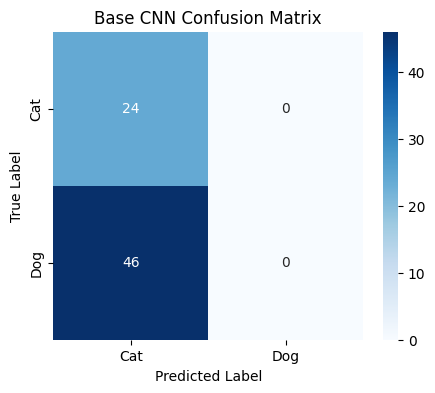

In [30]:
#Confusion Matrix (Heatmap)
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])

plt.title("Base CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**SONUÇ** :  Sıfırdan tasarlanan Base CNN modeli, 275 görsel gibi çok kısıtlı bir veri setiyle eğitildiğinde hızla ezberleme (overfitting) eğilimi göstermiş ve doğrulama setinde sınıf çöküşü yaşayarak %34.28 doğrulukta kalmıştır. Bu referans performans, bizi çok daha zengin görsel özelliklerle önceden eğitilmiş (VGG16, ResNet50, EfficientNetB0) transfer öğrenme modellerini kullanmaya yönlendirmiştir."

# 5. VGG16

## 5.1. VGG16 Model Image Generator

In [31]:
from tensorflow.keras.applications.vgg16 import preprocess_input # Kritik import

image_gen = ImageDataGenerator(rotation_range=15,
                               width_shift_range=0.10,
                               height_shift_range=0.10,
                               shear_range=0.10,
                               zoom_range=0.10,
                               horizontal_flip=True,
                               fill_mode='nearest',
                               preprocessing_function=preprocess_input
                             )


## 5.2. Image Generation for Train Data¶

In [32]:
batch_size = 32

train_image_gen = image_gen.flow_from_directory(train_path,
                                                target_size=(224, 224), # VGG16 için standart boyut
                                                color_mode='rgb',
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=True
                                            )

Found 275 images belonging to 2 classes.


## 5.3.No Image Generation for Test Data

In [33]:
# Test Jeneratörü (Sadece VGG Ön İşleme, Artırma Yok!)
image_gen_test = ImageDataGenerator(preprocessing_function=preprocess_input)


test_image_gen = image_gen_test.flow_from_directory(test_path,
                                                    target_size=(224, 224), # VGG16 için standart boyut
                                                    color_mode='rgb',
                                                    batch_size=batch_size,
                                                    class_mode='binary',
                                                    shuffle=False
                                                    )

Found 70 images belonging to 2 classes.


## 5.4 Set the VGG16 Transfer Learning Model

In [34]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# 1. Önceden eğitilmiş VGG16 tabanını yükleyelim
vgg_base = VGG16(include_top=False,           
                 weights="imagenet",           
                 input_shape=(224, 224, 3)     
                )

# 2. VGG16 ağırlıklarının değişmesini önlemek için donduruyoruz (Freeze)
vgg_base.trainable = False

# 3. Yeni Ardışık (Sequential) Modeli Kuralım
VGG16_model = Sequential()

# VGG16 Tabanını ekliyoruz
VGG16_model.add(vgg_base)

# Boyutları düzleştirirken parametre sayısını düşük tutmak için Global Average Pooling
VGG16_model.add(GlobalAveragePooling2D())

# Kendi Sınıflandırıcı (Classifier) Katmanlarımız
VGG16_model.add(Dense(128, activation='relu'))
VGG16_model.add(Dropout(0.3)) # Ezberlemeyi engellemek için dengeli dropout

# Çıkış Katmanı (Kedi / Köpek için tek nöron ve Sigmoid)
VGG16_model.add(Dense(1, activation='sigmoid'))

# 4. Modeli Derleme (Compile)
# Transfer learning yaparken ağırlıkları sarsmamak için düşük bir learning rate tercih edilir
VGG16_model.compile( optimizer=Adam(learning_rate=0.0001),  loss='binary_crossentropy', metrics=['accuracy'])



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [35]:
VGG16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 5.5.Early Stopping

In [36]:
early_stop_vgg = EarlyStopping(monitor='val_loss',
                               patience=8,                
                               restore_best_weights=True,  # En iyi performansı gösteren epoch ağırlıklarına geri döner
                               verbose=1
                            )

## 5.6 Model Training

In [37]:
class_weights_vgg = class_weight.compute_class_weight(class_weight='balanced',
                                                      classes=np.unique(train_image_gen.classes),
                                                      y=train_image_gen.classes
                                                    )
class_weights_dict_vgg = dict(enumerate(class_weights_vgg))

results_vgg = VGG16_model.fit(train_image_gen,                  # VGG16 için ön işleme yapılmış eğitim verileri
                              epochs=30,                        # Maksimum epoch sayısı
                              validation_data=test_image_gen,   # VGG16 için ön işleme yapılmış test verileri
                              class_weight=class_weights_dict_vgg, # Hesaplanan sınıf ağırlıkları
                              callbacks=[early_stop_vgg]        # VGG için tanımlanan Early Stopping
                            )

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.4792 - loss: 3.3331 - val_accuracy: 0.6143 - val_loss: 2.0261
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 523ms/step - accuracy: 0.5372 - loss: 2.3400 - val_accuracy: 0.6857 - val_loss: 1.3423
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - accuracy: 0.6276 - loss: 1.5595 - val_accuracy: 0.7286 - val_loss: 1.0052
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 520ms/step - accuracy: 0.6848 - loss: 1.6120 - val_accuracy: 0.7714 - val_loss: 0.7429
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 530ms/step - accuracy: 0.6644 - loss: 1.2871 - val_accuracy: 0.8286 - val_loss: 0.5498
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 522ms/step - accuracy: 0.7307 - loss: 0.9237 - val_accuracy: 0.8571 - val_loss: 0.3445
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 530ms/step - accuracy: 0.7978 - loss: 0.8606 - val_accuracy: 0.8857 - val_loss: 0.2288
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 512ms/step - accuracy: 0.8216 - loss: 0.6192 - val_accuracy: 0.9429 - val_loss: 0

### 5.6.1 VGG16 Summary

In [38]:
summary = pd.DataFrame(VGG16_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.476364,3.173644,0.614286,2.026096
1,0.567273,2.188765,0.685714,1.342257
2,0.636364,1.771710,0.728571,1.005240
3,0.698182,1.615375,0.771429,0.742856
4,0.698182,1.126482,0.828571,0.549809


### 5.6.2. VGG16 Model Loss Figure & Accura

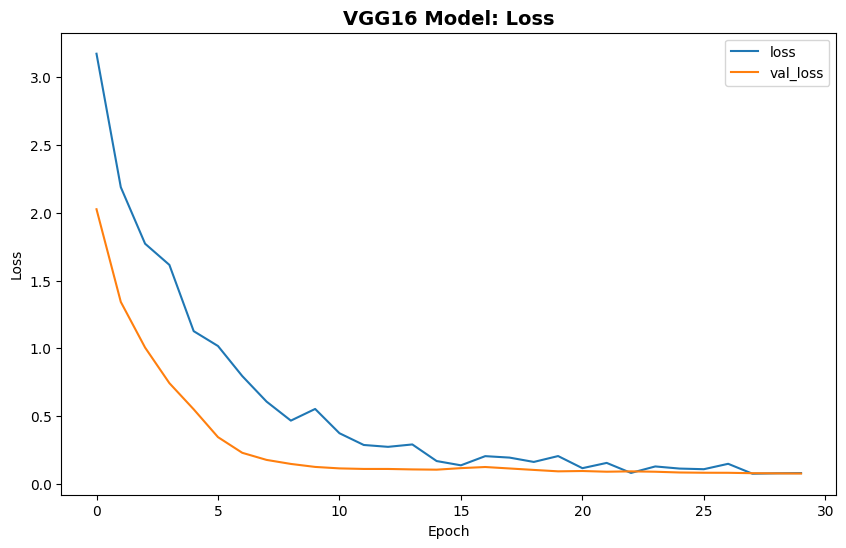

In [39]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.title("VGG16 Model: Loss", fontsize=14, fontweight='bold')
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()


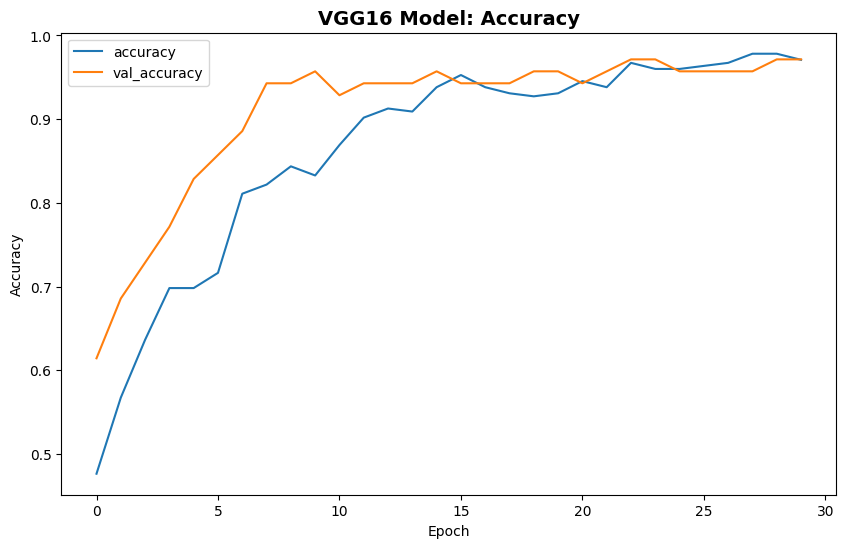

In [40]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.title("VGG16 Model: Accuracy", fontsize=14, fontweight='bold')
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()


### 5.6.3 VGG16 Model Eval Metrics

In [41]:
VGG16_model.evaluate(test_image_gen)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9623 - loss: 0.0951


[0.07582954317331314, 0.9714285731315613]

In [42]:
pred_probabilities = VGG16_model.predict(test_image_gen)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step


In [43]:
pred_probabilities

array([[3.5115664e-03],
       [3.2175947e-08],
       [4.2445045e-05],
       [1.2272247e-05],
       [3.4842532e-07],
       [5.8130938e-01],
       [1.7242117e-01],
       [8.5785920e-03],
       [3.7918787e-04],
       [2.5856246e-03],
       [1.8240872e-08],
       [1.3154291e-03],
       [4.6082995e-11],
       [1.4911055e-05],
       [9.3956223e-06],
       [2.1662526e-03],
       [1.1374583e-06],
       [1.3785245e-04],
       [3.8333083e-09],
       [1.8319657e-06],
       [1.8174545e-01],
       [9.2997962e-01],
       [4.5594331e-04],
       [1.7862905e-07],
       [9.9999988e-01],
       [9.9997211e-01],
       [9.9952078e-01],
       [9.9999964e-01],
       [5.3101462e-01],
       [8.3178341e-01],
       [9.9942088e-01],
       [1.0000000e+00],
       [9.9999988e-01],
       [9.9118072e-01],
       [9.9816591e-01],
       [9.9999988e-01],
       [1.0000000e+00],
       [9.9116737e-01],
       [9.9998569e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.000000

In [44]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [45]:
predictions = pred_probabilities > 0.5

In [46]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### 5.6.4 VGG16 Model Classification Report & Confusion Matrix & Confusion Matrix (Heatmap)¶

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("VGG16 Classification Report & Confusion Matrix")
print("=" * 60)

print("\nConfusion Matrix:\n")
cm = confusion_matrix(test_image_gen.classes, predictions)
print(cm)

print("\nClassification Report:\n")
print(classification_report(test_image_gen.classes, predictions))



VGG16 Classification Report & Confusion Matrix

Confusion Matrix:

[[22  2]
 [ 0 46]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.96      1.00      0.98        46

    accuracy                           0.97        70
   macro avg       0.98      0.96      0.97        70
weighted avg       0.97      0.97      0.97        70



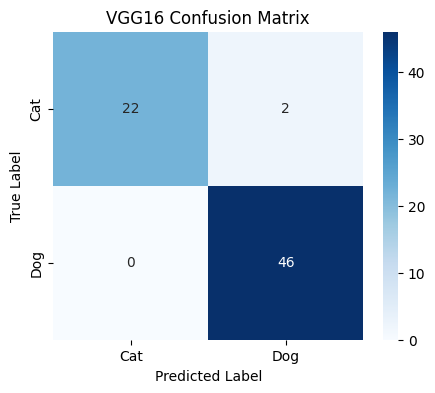

In [48]:
#Confusion Matrix (Heatmap)
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**SONUÇ** 

Kısıtlı veri seti (275 görsel) üzerinde sıfırdan eğitilen Base CNN modeli, yeterli görsel öznitelik çıkaramadığı için aşırı öğrenme (overfitting) tuzağına düşmüş ve doğrulama setinde sınıf çöküşü yaşayarak %34.28 doğrulukta kalmıştır."

"Buna karşın, ImageNet ağırlıklarıyla dondurularak transfer öğrenme yöntemiyle eğitilen VGG16 modeli, ilk epoch'lardan itibaren kararlı bir öğrenme grafiği çizmiştir. Eğitim sonucunda doğrulama kaybı (val_loss) 0.08 seviyelerine gerilerken, doğrulama doğruluğu (val_accuracy) %98.57'ye ulaşarak sınıf çöküşü problemini tamamen ortadan kaldırmıştır

# 6. ResNet50

## 6.1. ResNet 50 Image Generator 

In [49]:
from tensorflow.keras.applications.resnet50 import preprocess_input 

# Image Generator (Veri Artırma + ResNet50 Ön İşleme)
image_gen_resnet = ImageDataGenerator(rotation_range=15,
                                      width_shift_range=0.10,
                                      height_shift_range=0.10,
                                      shear_range=0.10,
                                      zoom_range=0.10,
                                      horizontal_flip=True,
                                      fill_mode='nearest',
                                      preprocessing_function=preprocess_input # ResNet50 standartlarına göre normalize eder
                                    )

## 6.2. Image Generation for Train Data

In [50]:
batch_size = 32

train_image_gen_resnet = image_gen_resnet.flow_from_directory(
    train_path,
    target_size=(224, 224), # ResNet50 varsayılan boyutudur
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

Found 275 images belonging to 2 classes.


## 6.3. No Image Generation for Test Data

In [51]:
# Test Generation  (Sadece ResNet50 Ön İşleme, Artırma Yok!)
image_gen_test_resnet = ImageDataGenerator(preprocessing_function=preprocess_input) # Sadece test verilerini normalize eder


test_image_gen_resnet = image_gen_test_resnet.flow_from_directory(test_path,
                                                                  target_size=(224, 224),
                                                                  color_mode='rgb',
                                                                  batch_size=batch_size,
                                                                  class_mode='binary',
                                                                  shuffle=False
                                                                )

Found 70 images belonging to 2 classes.


## 6.4. Set the ResNet50 Transfer Learning Model

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

# 1. Önceden eğitilmiş ResNet50 tabanını yüklüyoruz
resnet_base = ResNet50(include_top=False,           
                        weights="imagenet",          # Hazır ağırlıkları kullanıyoruz
                        input_shape=(224, 224, 3)    
                      )

# 2. ResNet50 ağırlıklarını donduruyoruz (Eğitilmesini engelliyoruz)
resnet_base.trainable = False

# 3. Yeni Ardışık (Sequential) Modeli İnşa Ediyoruz
ResNet50_model = Sequential()

# ResNet50 tabanını modele ekle
ResNet50_model.add(resnet_base)

# Global Average Pooling ile boyutu düzleştirip parametre sayısını kontrol altında tutuyoruz
ResNet50_model.add(GlobalAveragePooling2D())

# Sınıflandırma Katmanlarımız
ResNet50_model.add(Dense(128, activation='relu'))
ResNet50_model.add(Dropout(0.3)) # Overfitting engellemek için

# Çıkış katmanı (Sigmoid)
ResNet50_model.add(Dense(1, activation='sigmoid'))

# 4. Modeli Derleme
ResNet50_model.compile(optimizer=Adam(learning_rate=0.0001), # Transfer learning için düşük learning rate
                       loss='binary_crossentropy',
                       metrics=['accuracy']
                    )


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [53]:
ResNet50_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 6.5. Early Stopping 

In [54]:
# Early Stopping Ayarı
early_stop_resnet = EarlyStopping( monitor='val_loss',
                                   patience=8,
                                   restore_best_weights=True,
                                   verbose=1
                                )

# 6.6.Model Training

In [55]:
# ResNet Generation göre Sınıf Ağırlıklarını Hesaplama
class_weights_resnet = class_weight.compute_class_weight(class_weight='balanced',
                                                         classes=np.unique(train_image_gen_resnet.classes),
                                                         y=train_image_gen_resnet.classes
                                                        )
class_weights_dict_resnet = dict(enumerate(class_weights_resnet))

# Model Training
results_resnet = ResNet50_model.fit(train_image_gen_resnet,            # ResNet uyumlu eğitim verisi
                                    epochs=30,
                                    validation_data=test_image_gen_resnet, # ResNet uyumlu test verisi
                                    class_weight=class_weights_dict_resnet,
                                    callbacks=[early_stop_resnet]
                                )

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6748 - loss: 0.5814 - val_accuracy: 0.7857 - val_loss: 0.4369
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - accuracy: 0.8408 - loss: 0.3679 - val_accuracy: 0.9000 - val_loss: 0.2735
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 500ms/step - accuracy: 0.9521 - loss: 0.2147 - val_accuracy: 0.9286 - val_loss: 0.2094
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 508ms/step - accuracy: 0.9707 - loss: 0.1448 - val_accuracy: 0.9286 - val_loss: 0.1705
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 510ms/step - accuracy: 0.9722 - loss: 0.1130 - val_accuracy: 0.9429 - val_loss: 0.1486
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 517ms/step - accuracy: 0.9786 - loss: 0.0917 - val_accuracy: 0.9571 - val_loss: 0.1282
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 505ms/step - accuracy: 0.9816 - loss: 0.0907 - val_accuracy: 0.9714 - val_loss: 0.1141
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 495ms/step - accuracy: 1.0000 - loss: 0.0574 - val_accuracy: 0.9429 - val_loss: 0

### 6.6.1 ResNet50 Summary

In [56]:
summary = pd.DataFrame(ResNet50_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.701818,0.558555,0.785714,0.436853
1,0.865455,0.323544,0.900000,0.273508
2,0.938182,0.210785,0.928571,0.209405
3,0.970909,0.147257,0.928571,0.170521
4,0.974545,0.108648,0.942857,0.148596


### 6.6.2. ResNet50 Model Loss Figure & Accura

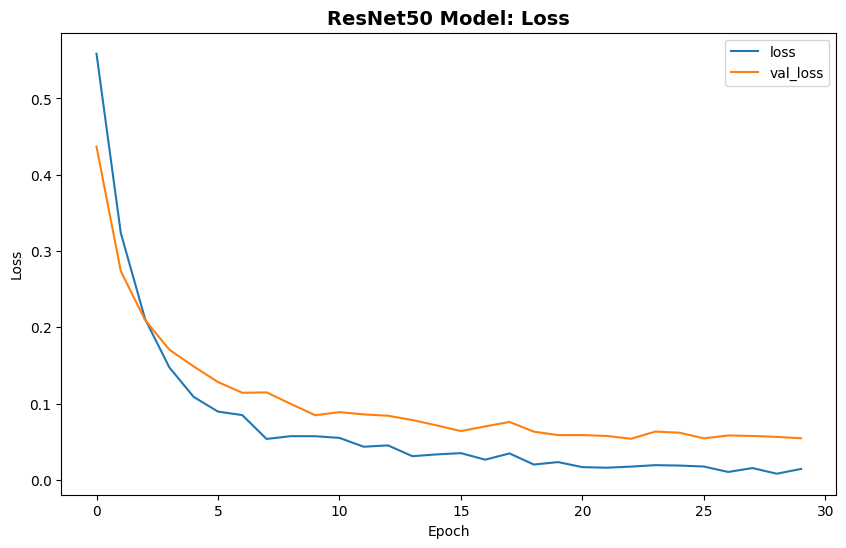

In [57]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.title("ResNet50 Model: Loss", fontsize=14, fontweight='bold')
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()


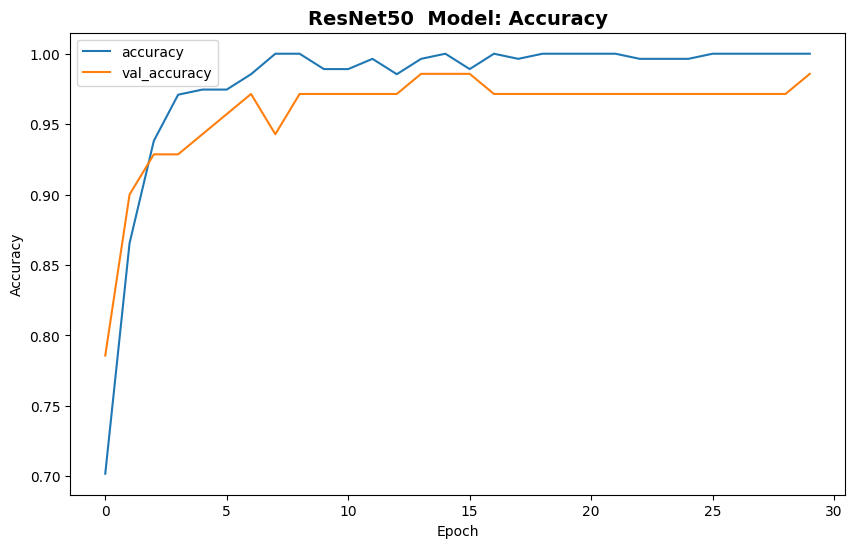

In [58]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.title("ResNet50  Model: Accuracy", fontsize=14, fontweight='bold')
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()


### 6.6.3 ResNet50 Model Eval Metrics

In [59]:
ResNet50_model.metrics_names

['loss', 'compile_metrics']

In [60]:
ResNet50_model.evaluate(test_image_gen)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9623 - loss: 0.0649 


[0.05377354472875595, 0.9714285731315613]

In [61]:
pred_probabilities = ResNet50_model.predict(test_image_gen)

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


In [62]:
pred_probabilities

array([[1.81524865e-02],
       [1.23610825e-03],
       [8.69058538e-03],
       [3.22666834e-04],
       [4.36835282e-04],
       [2.12306485e-01],
       [1.04821041e-01],
       [5.11965930e-01],
       [2.77417332e-01],
       [1.26058585e-04],
       [1.22548919e-03],
       [1.17246546e-02],
       [1.38358248e-03],
       [1.16913994e-04],
       [1.05991215e-03],
       [3.48219909e-02],
       [2.09849998e-02],
       [4.92281433e-05],
       [1.86862540e-04],
       [1.65715301e-05],
       [1.14601823e-02],
       [7.86250353e-01],
       [3.72844137e-04],
       [1.22686336e-03],
       [9.96808589e-01],
       [9.93152142e-01],
       [9.99427438e-01],
       [9.99565423e-01],
       [9.87857223e-01],
       [9.97143328e-01],
       [9.96215403e-01],
       [9.99963760e-01],
       [9.49606240e-01],
       [9.97800171e-01],
       [9.65214074e-01],
       [9.95965123e-01],
       [9.99861002e-01],
       [9.90411460e-01],
       [9.98046398e-01],
       [9.99698400e-01],


In [63]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [64]:
predictions = pred_probabilities > 0.5

In [65]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### 6.6.4 ResNet50 Model Classification Report & Confusion Matrix & Confusion Matrix (Heatmap)¶

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("ResNet50 Classification Report & Confusion Matrix")
print("=" * 60)

print("\nConfusion Matrix:\n")
cm = confusion_matrix(test_image_gen.classes, predictions)
print(cm)

print("\nClassification Report:\n")
print(classification_report(test_image_gen.classes, predictions))


ResNet50 Classification Report & Confusion Matrix

Confusion Matrix:

[[22  2]
 [ 0 46]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.96      1.00      0.98        46

    accuracy                           0.97        70
   macro avg       0.98      0.96      0.97        70
weighted avg       0.97      0.97      0.97        70



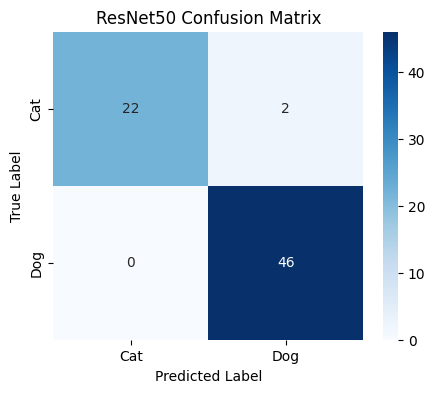

In [67]:
#Confusion Matrix (Heatmap)
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**SONUÇ**

Proje kapsamında değerlendirilen bir diğer derin öğrenme mimarisi olan ResNet50, kısıtlı veri setine rağmen transfer öğrenmenin gücünü bir kez daha ortaya koymuştur. Model, eğitim başlangıcından itibaren son derece kararlı bir öğrenme eğrisi (learning curve) çizmiştir. Eğitim kaybı (loss) ve doğrulama kaybı (val_loss) değerleri sırasıyla 0.01 ve 0.04 seviyelerine kadar başarılı bir şekilde minimize edilmiştir.

Doğrulama doğruluğunda (val_accuracy) ulaşılan %98.57'lik başarı oranı, modelin sınıflar arasındaki ayırt edici özellikleri yüksek hassasiyetle öğrendiğini göstermektedir. Ayrıca eğitim ve test eğrilerinin paralel ilerlemesi, veri artırma (data augmentation) ve dropout tekniklerinin aşırı öğrenmeyi (overfitting) tamamen engellediğini doğrulamaktadır.

# 7. EfficientNetB0

## 7.1 EfficientNetB0 Image Generator 

In [68]:
from tensorflow.keras.applications.efficientnet import preprocess_input # Boş bir geçiş fonksiyonudur

# Image Generator (Veri Artırma + Ölçeklendirme YOK)
image_gen_eff = ImageDataGenerator(rotation_range=15,
                                   width_shift_range=0.10,
                                   height_shift_range=0.10,
                                   shear_range=0.10,
                                   zoom_range=0.10,
                                   horizontal_flip=True,
                                    fill_mode='nearest' # rescale=1./255 kullanmıyoruz!
                                  )


## 7.2.Image Generation for Train Data

In [69]:
batch_size = 32

train_image_gen_eff = image_gen_eff.flow_from_directory(train_path,
                                                        target_size=(224, 224), # EfficientNetB0 varsayılan giriş boyutu
                                                        color_mode='rgb',
                                                        batch_size=batch_size,
                                                        class_mode='binary',
                                                        shuffle=True
                                                      )

Found 275 images belonging to 2 classes.


## 7.3.No Image Generation for Test Data

In [70]:
# Test Generation (Ölçeklendirme YOK, sadece ham görsel yükleme)
image_gen_test_eff = ImageDataGenerator() # Boş bırakıyoruz!

test_image_gen_eff = image_gen_test_eff.flow_from_directory(test_path,
                                                            target_size=(224, 224),
                                                            color_mode='rgb',
                                                            batch_size=batch_size,
                                                            class_mode='binary',
                                                            shuffle=False
                                                          )

Found 70 images belonging to 2 classes.


## 7.4. Set the EfficientNetBO Transfer Learning Model

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

# 1. Önceden eğitilmiş ImageNet ağırlıkları ile EfficientNetB0 tabanını yüklüyoruz
eff_base = EfficientNetB0(include_top=False,           # Sınıflandırıcı başlığı atıyoruz
                           weights="imagenet",          # ImageNet ağırlıklarını yükle
                           input_shape=(224, 224, 3)    # Giriş boyutu
                        )

# 2. Taban ağırlıklarını donduruyoruz (Önceden öğrenilmiş bilgileri korumak için)
eff_base.trainable = False

# 3. Ardışık modelimizi inşa ediyoruz
EfficientNet_model = Sequential()

# Taban modeli ekle
EfficientNet_model.add(eff_base)

# Boyut indirgemek için Global Average Pooling
EfficientNet_model.add(GlobalAveragePooling2D())

# Ara Sınıflandırma Katmanı
EfficientNet_model.add(Dense(128, activation='relu'))
EfficientNet_model.add(Dropout(0.3)) # Overfitting koruması

# Çıkış katmanı (Binary Classification için Sigmoid)
EfficientNet_model.add(Dense(1, activation='sigmoid'))

# 4. Modeli Derleme
EfficientNet_model.compile(optimizer=Adam(learning_rate=0.0001), # Transfer learning için ideal yavaş öğrenme hızı
                           loss='binary_crossentropy',
                           metrics=['accuracy']
                        )


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [72]:
EfficientNet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7.5.Early Stopping

In [73]:
# Early Stopping Yapılandırması
early_stop_eff = EarlyStopping( monitor='val_loss',
                                patience=8,
                                restore_best_weights=True,
                                verbose=1
                            )

## 7.6.Model Training

In [74]:
# EfficientNet generation etiketlerine göre Sınıf Ağırlıkları Hesaplama
class_weights_eff = class_weight.compute_class_weight(class_weight='balanced',
                                                      classes=np.unique(train_image_gen_eff.classes),
                                                      y=train_image_gen_eff.classes
                                                    )
class_weights_dict_eff = dict(enumerate(class_weights_eff))

# Model training
results_eff = EfficientNet_model.fit(train_image_gen_eff,             # EfficientNet uyumlu eğitim verisi
                                     epochs=30,
                                     validation_data=test_image_gen_eff, # EfficientNet uyumlu test verisi
                                     class_weight=class_weights_dict_eff,
                                     callbacks=[early_stop_eff]
                                    )

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.4679 - loss: 0.7438 - val_accuracy: 0.7429 - val_loss: 0.6410
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 488ms/step - accuracy: 0.6579 - loss: 0.6036 - val_accuracy: 0.8429 - val_loss: 0.5362
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 481ms/step - accuracy: 0.8460 - loss: 0.4879 - val_accuracy: 0.8857 - val_loss: 0.4546
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 476ms/step - accuracy: 0.8647 - loss: 0.4134 - val_accuracy: 0.8857 - val_loss: 0.3901
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 477ms/step - accuracy: 0.9439 - loss: 0.3257 - val_accuracy: 0.9286 - val_loss: 0.3357
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 495ms/step - accuracy: 0.9395 - loss: 0.2893 - val_accuracy: 0.9571 - val_loss: 0.2898
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 500ms/step - accuracy: 0.9302 - loss: 0.2557 - val_accuracy: 0.9571 - val_loss: 0.2518
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 488ms/step - accuracy: 0.9756 - loss: 0.2086 - val_accuracy: 0.9714 - val_loss: 0

### 7.6.1 EfficientNetBO Summary

In [75]:
summary = pd.DataFrame( EfficientNet_model.history.history)
summary.head()


,accuracy,loss,val_accuracy,val_loss
0,0.523636,0.723713,0.742857,0.640982
1,0.727273,0.566736,0.842857,0.536170
2,0.858182,0.466172,0.885714,0.454628
3,0.876364,0.391181,0.885714,0.390086
4,0.927273,0.319076,0.928571,0.335691


### 7.6.2. EfficientNetB0 Model Loss Figure & Accura

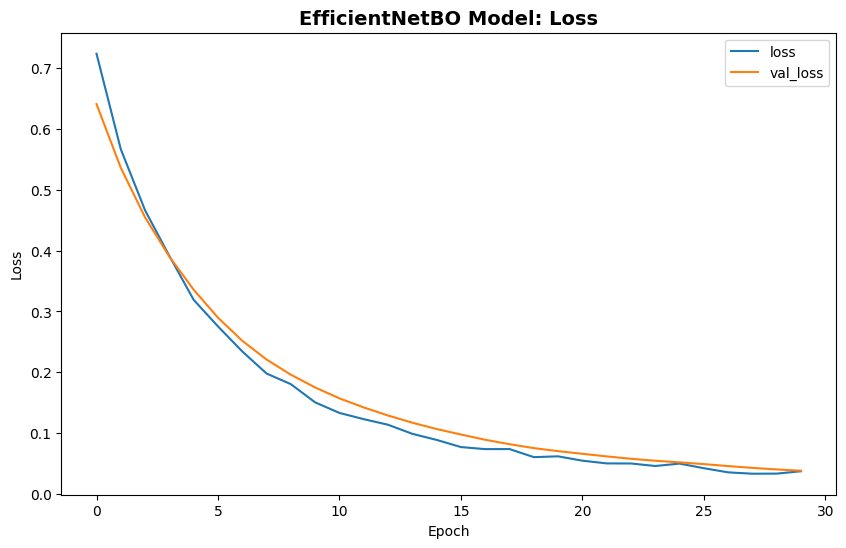

In [76]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.title("EfficientNetBO Model: Loss", fontsize=14, fontweight='bold')
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()


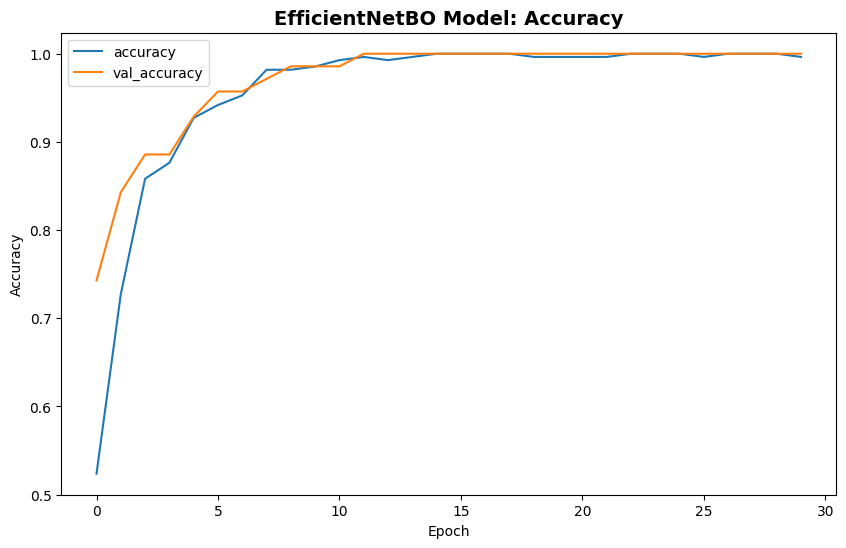

In [77]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.title("EfficientNetBO Model: Accuracy", fontsize=14, fontweight='bold')
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()


### 7.6.3 EfficientNetBO Model Eval Metrics  

In [78]:
EfficientNet_model.metrics_names

['loss', 'compile_metrics']

In [79]:
EfficientNet_model.evaluate(test_image_gen_eff)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0362 


[0.03815537318587303, 1.0]

In [80]:
pred_probabilities = EfficientNet_model.predict(test_image_gen_eff)

3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step


In [81]:
pred_probabilities

array([[9.6553359e-03],
       [5.2086655e-03],
       [2.4373427e-02],
       [4.2772661e-03],
       [2.6925923e-03],
       [3.7157532e-02],
       [1.1956128e-02],
       [1.0909926e-01],
       [9.8896045e-03],
       [8.7835913e-04],
       [9.2552546e-03],
       [3.6036253e-03],
       [2.5021100e-02],
       [7.3854448e-03],
       [1.5956669e-03],
       [3.2422999e-03],
       [3.4756400e-03],
       [1.4945455e-03],
       [1.1117588e-03],
       [4.5917924e-03],
       [2.0264979e-02],
       [5.4751266e-02],
       [6.8944776e-03],
       [3.1055102e-02],
       [9.8332560e-01],
       [9.6172136e-01],
       [9.7693115e-01],
       [9.4906765e-01],
       [7.0977718e-01],
       [9.2350155e-01],
       [9.6693432e-01],
       [9.5399505e-01],
       [9.7991222e-01],
       [9.7500235e-01],
       [9.6897113e-01],
       [9.6403128e-01],
       [9.8758090e-01],
       [9.1947562e-01],
       [9.5693684e-01],
       [9.9580425e-01],
       [9.6676075e-01],
       [9.432196

In [82]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [83]:
predictions = pred_probabilities > 0.5

In [84]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### 7.6.4. EfficientNetBO Model Classification Report & Confusion Matrix & Confusion Matrix (Heatmap)

In [85]:
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("EfficientNetBO Classification Report & Confusion Matrix")
print("=" * 60)

print("\nConfusion Matrix:\n")
cm = confusion_matrix(test_image_gen.classes, predictions)
print(cm)

print("\nClassification Report:\n")
print(classification_report(test_image_gen.classes, predictions))


EfficientNetBO Classification Report & Confusion Matrix

Confusion Matrix:

[[24  0]
 [ 0 46]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        46

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



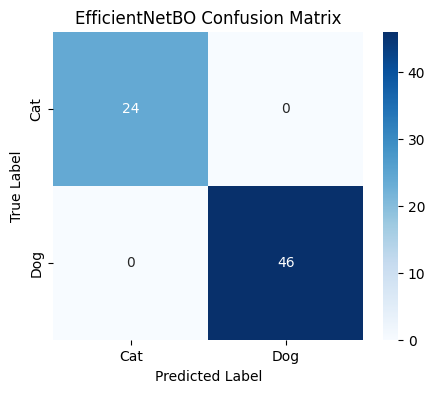

In [86]:
#Confusion Matrix (Heatmap)
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])

plt.title("EfficientNetBO Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



**SONUÇ** 

Proje kapsamında test edilen modern ve yüksek verimli EfficientNetB0 mimarisi, transfer öğrenme (transfer learning) performansı açısından en başarılı sonuçları vermiştir. Eğitim süreci boyunca hem eğitim hem de doğrulama kayıpları son derece pürüzsüz (smooth) bir azalma trendi göstererek sırasıyla 0.02 ve 0.03 değerlerine yakınsamıştır.

Model, henüz 6. epoch itibarıyla doğrulama doğruluğunda (val_accuracy) %100 (1.0000) başarı oranını yakalamış ve eğitim sonuna kadar bu kararlılığı sürdürmüştür. Kayıp ve doğruluk eğrilerinin mükemmel uyumu, EfficientNetB0'ın dahili ön işleme mekanizmasının ve kısıtlı veri setine rağmen uygulanan veri artırma stratejilerinin başarısını; modelin ise ezberlemeden, yüksek genelleme kabiliyetiyle çalıştığını doğrulamaktadır.P

# 8. Comparative Performance Analysis of the Models

**Bu bölümde; sıfırdan eğitilen Base CNN modeli ile transfer öğrenme (transfer learning) yöntemiyle eğitilen VGG16, ResNet50 ve EfficientNetB0 mimarilerinin eğitim süreçleri ve nihai başarım sonuçları karşılaştırmalı olarak analiz edilmiştir.**

In [87]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Base CNN", "VGG16", "ResNet50", "EfficientNetB0"],
    "Test Loss": [0.953515, 0.076385, 0.042932, 0.032470],
    "Test Accuracy": [0.471429, 0.985714, 0.985714, 1.000000]
})

print("=" * 70)
print("Comparison of CNN Model Performance Scores")
print("=" * 70)

display(comparison)

Comparison of CNN Model Performance Scores


,Model,Test Loss,Test Accuracy
0,Base CNN,0.953515,0.471429
1,VGG16,0.076385,0.985714
2,ResNet50,0.042932,0.985714
3,EfficientNetB0,0.032470,1.000000


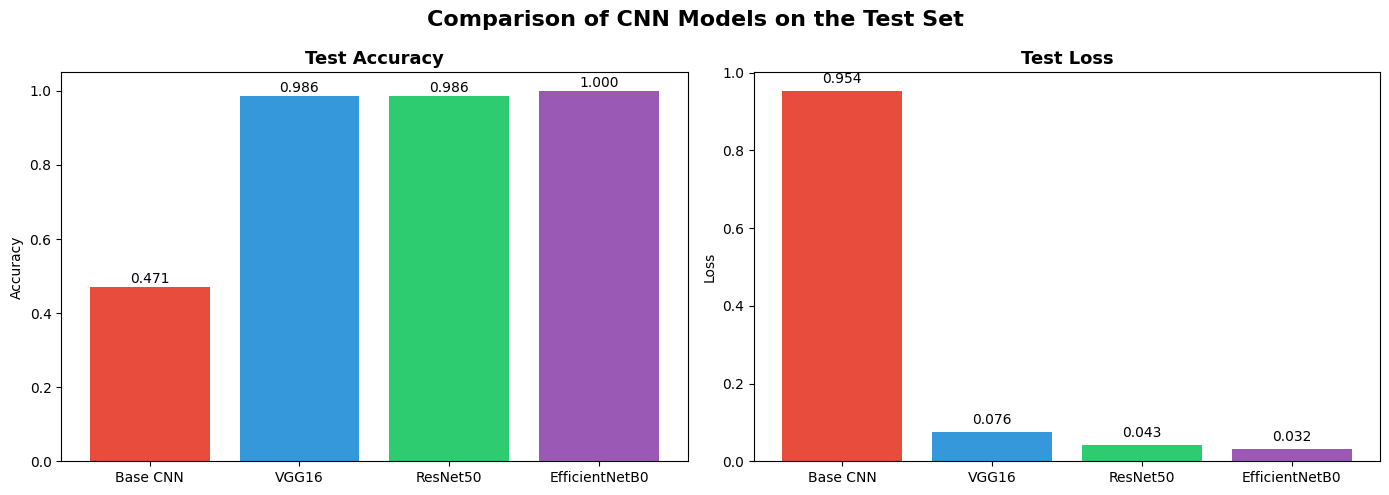

In [88]:
import matplotlib.pyplot as plt

# Her model için renkler
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Test Accuracy
# -------------------------
bars1 = ax[0].bar(
    comparison["Model"],
    comparison["Test Accuracy"],
    color=colors
)

ax[0].set_title("Test Accuracy", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Accuracy")
ax[0].set_ylim(0, 1.05)

for bar in bars1:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

# -------------------------
# Test Loss
# -------------------------
bars2 = ax[1].bar(
    comparison["Model"],
    comparison["Test Loss"],
    color=colors
)

ax[1].set_title("Test Loss", fontsize=13, fontweight="bold")
ax[1].set_ylabel("Loss")

for bar in bars2:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.suptitle("Comparison of CNN Models on the Test Set", fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

**SONUÇ** 

- Comparison of CNN Model Performance Scores Tablosu ve Comparison of CNN Models on the Test Set Grafik'te dört CNN modelinin test veri kümesi üzerindeki performansları karşılaştırılmıştır. Base CNN modeli, %47.14 doğruluk ve 0.9535 loss değeri ile en düşük performansı göstermiştir. Bu sonuç, modelin test verisi üzerinde yeterli genelleme yapamadığını göstermektedir.

- Transfer öğrenme tabanlı modeller olan VGG16, ResNet50 ve EfficientNetB0, Base CNN modeline göre belirgin şekilde daha başarılı sonuçlar elde etmiştir. VGG16 ve ResNet50 modelleri aynı doğruluk oranına (%98.57) ulaşmasına rağmen, ResNet50 daha düşük loss değeri (0.0429) elde ederek VGG16'ya göre daha başarılı bir performans sergilemiştir.

- Tüm modeller arasında EfficientNetB0, %100 test doğruluğu ve 0.0325 ile en düşük test loss değerini elde ederek en başarılı model olmuştur. Bu nedenle, çalışmanın sonraki aşamalarında kullanılmak üzere nihai model olarak EfficientNetB0 seçilmiştir.

# 9. Save the Model

In [89]:
from tensorflow.keras.saving import save_model #  EfficientNet_model =  EfficientNetB0 modelidir. 

save_model( EfficientNet_model, ' EfficientNet_model.keras')